In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : MNIST Digit Classification
Algorithm : ResNet – PyTorch
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim

In [21]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

# target_transform = Lambda(
#     lambda y: torch.zeros(num_classes).scatter_(0, torch.tensor(y), 1)
# )

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [22]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [24]:
class LightResNet(nn.Module):
    def __init__(self,num_classes= 10):
        super(LightResNet, self).__init__()
        # ******************* stem ********************#
        self.stem= nn.Sequential(nn.Conv2d(in_channels=1,out_channels=16,
                                           kernel_size=5,padding=2,stride=1),
                                 nn.BatchNorm2d(16),
                                 nn.ReLU(),
                                 nn.MaxPool2d(kernel_size=2,stride=2))
        # ******************* body ********************#
        self.res1= Residual(16,16)
        self.res2= Residual(16,16)
        self.res3= Residual(16,16)
        
        self.res4= Residual(16,32)
        self.res5= Residual(32,32)
        self.res6= Residual(32,32)
        
        self.res7= Residual(32,64,s=2)
        self.res8= Residual(64,64)
        self.res9= Residual(64,64)
        
        self.res10= Residual(64,128,s=2)
        self.res11= Residual(128,128)
        self.res12= Residual(128,128)

        # ******************* head ********************#
        self.head= nn.Sequential(nn.AdaptiveAvgPool2d((2,2)),
                                 nn.Flatten(),
                                #  nn.Dropout(0.4),
                                 nn.LazyLinear(num_classes))
    def forward(self,x):
       # X: bs x 1 x H x W
       out= self.stem(x)
       out= self.res1(out)
       out= self.res2(out)
       out= self.res3(out)
       
       out= self.res4(out)
       out= self.res5(out)
       out= self.res6(out)
       
       out= self.res7(out)
       out= self.res8(out)
       out= self.res9(out)
       
       out= self.res10(out)
       out= self.res11(out)
       out= self.res12(out)
       
       out= self.head(out)
       return out

class Residual(nn.Module):
    def __init__(self,in_chns,out_chns,s=1):
        super(Residual, self).__init__()
        
        self.res_b= nn.Sequential(nn.Conv2d(in_channels=in_chns,out_channels=out_chns,
                                            kernel_size= 3,padding=1,stride=s),
                                  nn.BatchNorm2d(out_chns),
                                  nn.ReLU(),
                                  
                                  nn.Conv2d(in_channels=out_chns,out_channels=out_chns,
                                            kernel_size= 3,padding=1),
                                  nn.BatchNorm2d(out_chns)) 
        self.skip= nn.Identity() if (in_chns==out_chns and s==1 ) else nn.Conv2d(in_channels=in_chns,
                                                                     out_channels=out_chns,
                                                                     kernel_size=1,stride=s)
        self.relu= nn.ReLU()
    def forward(self,x):
        identity= self.skip(x) # x
        out= self.res_b(x)# f(x)
        out= identity + out # x + f(x)
        out= self.relu(out)
        return out 

In [25]:
model= LightResNet(num_classes= 10)
n_out=10

criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(params=model.parameters(),
                      lr=0.001)

In [ ]:
mse=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred= model(xbatch)
          optimizer.zero_grad()
          loss= criterion(ypred,ybatch.long())
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%500==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               mse.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'MSE({iter}:{i}): {loss:.6f} **** Acc:{accuracy:.3f}%')
               model.train()
mse=torch.tensor(mse)

plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

MSE(0:0): 2.489491 **** Acc:9.970%
MSE(0:5): 2.618687 **** Acc:11.160%
MSE(0:10): 2.125810 **** Acc:11.160%
MSE(0:15): 1.829996 **** Acc:11.160%
MSE(0:20): 1.570875 **** Acc:11.160%
MSE(0:25): 1.368542 **** Acc:11.520%
MSE(0:30): 1.240396 **** Acc:26.740%
MSE(0:35): 1.107005 **** Acc:50.120%
MSE(0:40): 1.026829 **** Acc:76.960%
MSE(0:45): 0.954655 **** Acc:81.830%
MSE(0:50): 0.898684 **** Acc:88.070%
MSE(0:55): 0.842183 **** Acc:82.100%
MSE(0:60): 0.798014 **** Acc:90.630%
MSE(0:65): 0.755966 **** Acc:80.080%
MSE(0:70): 0.720595 **** Acc:77.920%
MSE(0:75): 0.701807 **** Acc:89.140%
MSE(0:80): 0.682007 **** Acc:81.390%
MSE(0:85): 0.660159 **** Acc:81.240%
MSE(0:90): 0.642323 **** Acc:90.340%
MSE(0:95): 0.620684 **** Acc:87.890%
MSE(0:100): 0.603397 **** Acc:87.840%
MSE(0:105): 0.586615 **** Acc:90.330%
MSE(0:110): 0.567420 **** Acc:91.790%
MSE(0:115): 0.551661 **** Acc:92.450%
MSE(0:120): 0.537989 **** Acc:85.520%
MSE(0:125): 0.524496 **** Acc:82.380%
MSE(0:130): 0.512589 **** Acc:93.64

KeyboardInterrupt: 

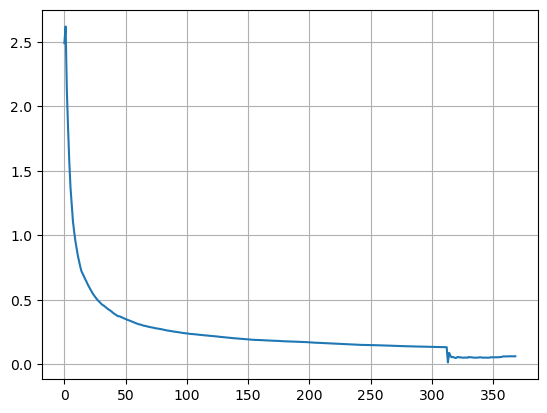

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(mse)
plt.grid()
plt.show()

Total accuracy:98.370%
accuracy0:99.286%
accuracy1:97.004%
accuracy2:98.353%
accuracy3:98.119%
accuracy4:99.491%
accuracy5:98.543%
accuracy6:97.182%
accuracy7:98.054%
accuracy8:98.973%
accuracy9:98.910%


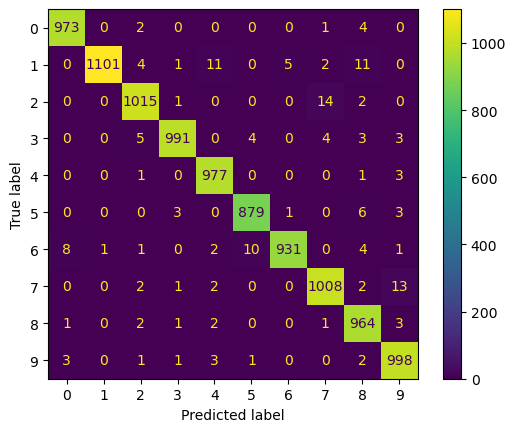

In [28]:
# validation
y_pred=[]
y_true=[]
model.eval()
with torch.no_grad():
    for i,(xbatch,ybatch) in enumerate(test_loader):
        # farward pass
        ypred= model(xbatch)
        ypred= torch.argmax(ypred,dim=1)
        y_pred.extend(ypred.numpy())
        y_true.extend(ybatch.numpy())
        
    y_pred= np.array(y_pred)
    y_true= np.array(y_true)

    from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
    #%% test trained Neural Network
    C= confusion_matrix(y_true,y_pred)
    # print(C)
    accuracy= np.sum(np.diag(C))/ np.sum(C) *100
    print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()